# Game24 Stats Analysis

This notebook is for the isolated Game24 offline pipeline outputs.
It loads merged `metadata.jsonl` and merged `metrics.jsonl`, then produces key statistics and plots.


In [19]:
from pathlib import Path
import json
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 200)


In [20]:
# Update these if you want to analyze a different run.
from pathlib import Path  # keeps this cell runnable standalone

MODEL_TAG = "qwen_qwen3_4b"
LIMIT = 500
REL_OUTPUT_BASE = Path("outputs/offline_game24_l500_r4096_k32_sh100")


def _detect_project_root(model_tag: str, limit: int) -> Path:
    rel_meta = REL_OUTPUT_BASE / f"{model_tag}_limit{limit}" / "merged" / "metadata.jsonl"
    candidates = [
        Path.cwd(),
        Path.cwd().resolve(),
        Path("/home/mila/z/zihan.wang/scratch/Learning_from_Retrospection"),
        Path("/network/scratch/z/zihan.wang/Learning_from_Retrospection"),
    ]
    candidates.extend(Path.cwd().resolve().parents)

    seen = set()
    for root in candidates:
        try:
            r = root.resolve()
        except Exception:
            r = root
        key = str(r)
        if key in seen:
            continue
        seen.add(key)
        if (r / rel_meta).exists():
            return r

    # Fallback: current directory (user can still override manually)
    return Path.cwd().resolve()


PROJECT_ROOT = _detect_project_root(MODEL_TAG, LIMIT)
OUTPUT_BASE = PROJECT_ROOT / REL_OUTPUT_BASE
RUN_DIR = OUTPUT_BASE / f"{MODEL_TAG}_limit{LIMIT}" / "merged"
METADATA_PATH = RUN_DIR / "metadata.jsonl"
METRICS_PATH = RUN_DIR / "analysis_parallel/merged/metrics.jsonl"

# Fast mode skips loading full response text (210MB file on this run).
LOAD_FULL_RESPONSE = True

print("PROJECT_ROOT:", PROJECT_ROOT)
print("RUN_DIR:", RUN_DIR)
print("METADATA_PATH exists:", METADATA_PATH.exists(), METADATA_PATH)
print("METRICS_PATH exists:", METRICS_PATH.exists(), METRICS_PATH)
print("LOAD_FULL_RESPONSE:", LOAD_FULL_RESPONSE)


PROJECT_ROOT: /network/scratch/z/zihan.wang/Learning_from_Retrospection
RUN_DIR: /network/scratch/z/zihan.wang/Learning_from_Retrospection/outputs/offline_game24_l500_r4096_k32_sh100/qwen_qwen3_4b_limit500/merged
METADATA_PATH exists: True /network/scratch/z/zihan.wang/Learning_from_Retrospection/outputs/offline_game24_l500_r4096_k32_sh100/qwen_qwen3_4b_limit500/merged/metadata.jsonl
METRICS_PATH exists: True /network/scratch/z/zihan.wang/Learning_from_Retrospection/outputs/offline_game24_l500_r4096_k32_sh100/qwen_qwen3_4b_limit500/merged/analysis_parallel/merged/metrics.jsonl
LOAD_FULL_RESPONSE: True


In [21]:
if not METADATA_PATH.exists():
    raise FileNotFoundError(f"Missing metadata file: {METADATA_PATH}")
if not METRICS_PATH.exists():
    raise FileNotFoundError(f"Missing metrics file: {METRICS_PATH}")

metrics = pd.read_json(METRICS_PATH, lines=True)

required_metric_cols = {
    "uid", "question_uid", "sample_idx", "success", "score_accuracy",
    "response_length", "analysis_length", "decay_rate", "ar_error"
}
missing_cols = sorted(required_metric_cols - set(metrics.columns))
if missing_cols:
    raise KeyError(f"Missing required metric columns: {missing_cols}")

# Load only metadata fields needed for analysis to keep startup fast.
meta_fields = ["uid", "is_possible", "has_think_tags", "has_answer_tags"]
if LOAD_FULL_RESPONSE:
    meta_fields.append("response")

meta_rows = []
with open(METADATA_PATH, "r", encoding="utf-8") as f:
    for line in f:
        row = json.loads(line)
        meta_rows.append({k: row.get(k) for k in meta_fields})
metadata = pd.DataFrame(meta_rows)

merged = metrics.merge(metadata, on="uid", how="left")
merged["is_possible"] = merged["is_possible"].fillna(False).astype(bool)

print("metadata rows:", len(metadata))
print("metrics rows:", len(metrics))
print("merged rows:", len(merged))
print("unique questions:", merged["question_uid"].nunique())
print("unique samples(uid):", merged["uid"].nunique())


metadata rows: 16000
metrics rows: 16000
merged rows: 16000
unique questions: 500
unique samples(uid): 16000


In [22]:
summary = {
    "overall_success_rate": float(merged["success"].mean()),
    "overall_accuracy_rate": float(merged["score_accuracy"].mean()),
    "mean_response_length": float(merged["response_length"].mean()),
    "median_response_length": float(merged["response_length"].median()),
    "p90_response_length": float(merged["response_length"].quantile(0.90)),
    "mean_ar_error": float(merged["ar_error"].mean()),
    "mean_decay_rate": float(merged["decay_rate"].mean()),
}
summary


{'overall_success_rate': 0.5796875,
 'overall_accuracy_rate': 0.5796875,
 'mean_response_length': 1754.036,
 'median_response_length': 1348.0,
 'p90_response_length': 4096.0,
 'mean_ar_error': 1.73184480118379,
 'mean_decay_rate': 1.3856974248376486}

In [23]:
possible_split = merged.groupby("is_possible").agg(
    n=("uid", "count"),
    success_rate=("success", "mean"),
    accuracy_rate=("score_accuracy", "mean"),
    response_length_mean=("response_length", "mean"),
    ar_error_mean=("ar_error", "mean"),
    decay_rate_mean=("decay_rate", "mean"),
).sort_index()
possible_split


,n,success_rate,accuracy_rate,response_length_mean,ar_error_mean,decay_rate_mean
is_possible,,,,,,
False,4160,0.489423,0.489423,2535.586538,1.538141,1.400496
True,11840,0.611402,0.611402,1479.437162,1.799903,1.380498


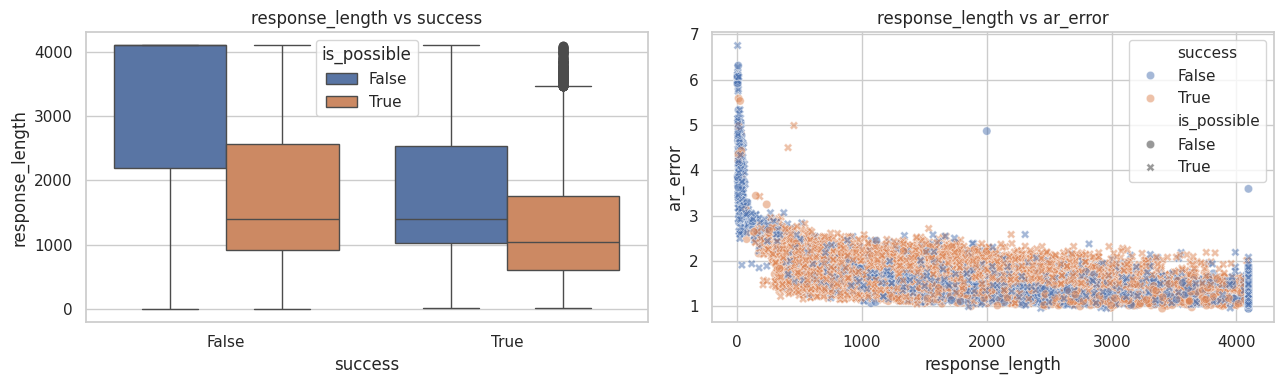

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
sns.boxplot(data=merged, x="success", y="response_length", hue="is_possible", ax=axes[0])
axes[0].set_title("response_length vs success")
axes[0].set_xlabel("success")
axes[0].set_ylabel("response_length")

sns.scatterplot(data=merged, x="response_length", y="ar_error", hue="success", style="is_possible", alpha=0.5, ax=axes[1])
axes[1].set_title("response_length vs ar_error")
axes[1].set_xlabel("response_length")
axes[1].set_ylabel("ar_error")

plt.tight_layout()


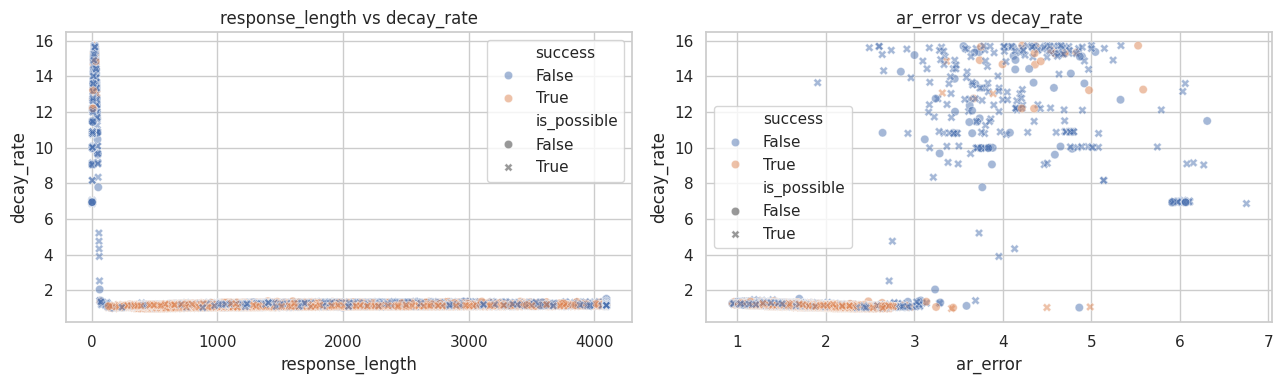

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
sns.scatterplot(data=merged, x="response_length", y="decay_rate", hue="success", style="is_possible", alpha=0.5, ax=axes[0])
axes[0].set_title("response_length vs decay_rate")
axes[0].set_xlabel("response_length")
axes[0].set_ylabel("decay_rate")

sns.scatterplot(data=merged, x="ar_error", y="decay_rate", hue="success", style="is_possible", alpha=0.5, ax=axes[1])
axes[1].set_title("ar_error vs decay_rate")
axes[1].set_xlabel("ar_error")
axes[1].set_ylabel("decay_rate")

plt.tight_layout()


mixed_outcome_questions: 498
mixed_outcome_rows: 15936


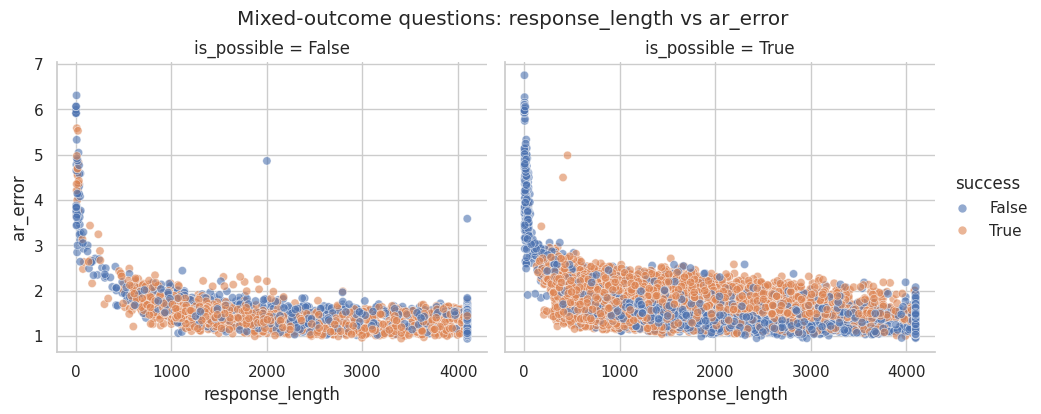

In [26]:
# Mixed-outcome question analysis: questions where both success and failure occur across samples.
q = merged.groupby("question_uid")["success"].agg(["min", "max"]).reset_index()
mixed_ids = set(q.loc[q["min"] != q["max"], "question_uid"].astype(str))
mixed = merged[merged["question_uid"].astype(str).isin(mixed_ids)].copy()
print("mixed_outcome_questions:", len(mixed_ids))
print("mixed_outcome_rows:", len(mixed))

if len(mixed) > 0:
    g = sns.relplot(
        data=mixed,
        x="response_length",
        y="ar_error",
        col="is_possible",
        hue="success",
        kind="scatter",
        alpha=0.6,
        height=4,
        aspect=1.2,
    )
    g.fig.suptitle("Mixed-outcome questions: response_length vs ar_error", y=1.03)


In [27]:
# Quick format-quality diagnostics for raw responses.
# In fast mode we avoid loading full `response`; tag diagnostics still work.
if "response" in merged.columns:
    diag = pd.DataFrame({
        "starts_with_close_think": merged["response"].fillna("").str.lstrip().str.startswith("</think>"),
        "has_open_think": merged["response"].fillna("").str.contains("<think>", regex=False),
        "has_close_think": merged["response"].fillna("").str.contains("</think>", regex=False),
        "has_answer_tags": merged["has_answer_tags"].fillna(False),
    })
else:
    diag = pd.DataFrame({
        "has_think_tags": merged["has_think_tags"].fillna(False),
        "has_answer_tags": merged["has_answer_tags"].fillna(False),
    })
    print("Full response text not loaded. Set LOAD_FULL_RESPONSE=True for token-level format diagnostics.")

diag.mean().to_frame("rate")


,rate
starts_with_close_think,0.330875
has_open_think,0.000063
has_close_think,0.844125
has_answer_tags,0.859125
